# Lecture 15: Structural estimation via SMM

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §10.3 (Joint $(\beta,\varrho)$ exercise) and §10.5 (BoTorch-BAL moment-map surrogate)  
**Notebook role:** extension  
**Author:** Simon Scheidegger  


In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


# Joint Structural Estimation via SMM: Brock--Mirman with $(\beta, \varrho)$

This is the natural extension of `03_Structural_Estimation_BM.ipynb`. There we estimated the persistence parameter $\varrho$ alone --- a textbook *just-identified* setup with a clean 1D objective. Here we let the **discount factor $\beta$** and the **persistence $\varrho$** be free *jointly*, and estimate both from a single moment vector.

The point of doing this with a neural surrogate is now sharper:
- The model would have to be re-solved for *every* $(\beta, \varrho)$ candidate during the optimizer's line-search. With a 4-input pseudo-state network we **train once** and evaluate millions of candidate moments at near-zero marginal cost.
- $\beta$ is *partially* identified by the macro moments at our disposal --- so the criterion will exhibit a visible **ridge** along the $\beta$ axis. The 2D objective contour makes this identification problem tangible.

### Workflow
1. Train a policy surrogate $(z, K, \beta, \varrho)\mapsto s$ on $\beta \in [0.92, 0.99]$, $\varrho \in [0.50, 0.99]$.
2. Generate synthetic ("ex-post") data at $(\beta_{\text{true}}, \varrho_{\text{true}}) = (0.96, 0.90)$ with a single fixed shock seed (Common Random Numbers).
3. Map the SMM criterion over the $(\beta, \varrho)$ grid -- visualize the ridge.
4. Compare a **just-identified** subset of moments versus an **over-identified** moment vector. Show how added moments collapse the ridge.
5. Estimate jointly with a bounded Nelder-Mead optimizer from the grid minimum; verify the solution is **interior**; check matched moments and policy fit ex post.

### References
- Azinovic, Gaegauf, and Scheidegger (2022), *International Economic Review*.
- McFadden (1989), Pakes and Pollard (1989), Gourieroux, Monfort, and Renault (1993).
- Iskrev (2010), Komunjer and Ng (2011) on identification.
- Chen, Didisheim, and Scheidegger (2026), *Journal of Financial Economics*.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize

np.random.seed(SEED)
torch.manual_seed(SEED)

def tensor_to_numpy(x):
    return np.asarray(x.detach().cpu().tolist())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.size"] = 13

def resolve_fig_dir():
    candidates = [Path("../../slides/fig"), Path("../slides/fig")]
    for candidate in candidates:
        if candidate.parent.exists():
            candidate.mkdir(parents=True, exist_ok=True)
            return candidate.resolve()
    fallback = Path("../slides/fig")
    fallback.mkdir(parents=True, exist_ok=True)
    return fallback.resolve()

fig_dir = resolve_fig_dir()
print(f"Figures will be saved to: {fig_dir}")

# Training budget is driven by RUN_MODE so the cell-1 switch is the single source of truth.
EP1 = {"smoke": 600, "teaching": 3000, "production": 8000}[RUN_MODE]
EP2 = {"smoke": 300, "teaching": 1200, "production": 3500}[RUN_MODE]
print(f"RUN_MODE: {RUN_MODE} ({EP1} + {EP2} episodes)")


Using device: cpu
PyTorch version: 2.2.1+cu121
Figures will be saved to: ../slides/fig
Training mode: classroom (3000 + 1200 episodes)


## Part 1 --- Train the joint pseudo-state surrogate

The state-cum-parameter vector is $X = (z, K, \beta, \varrho)$, and the network maps $X \mapsto s \in (0,1)$. The Euler residual is

$$\mathrm{eul}(X) = 1 - \beta C_t\,\mathbb{E}_t\!\left[\frac{1-\delta+r_{t+1}}{C_{t+1}}\right],$$

with the expectation evaluated by Gauss--Hermite on $\varepsilon$ and $\log z_{t+1}=\varrho\log z_t + \sigma\varepsilon$. Both $\beta$ and $\varrho$ enter the residual, so the surrogate must be trained over the full parameter rectangle before it can be used inside SMM.

In [2]:
# Calibrated parameters (kept fixed).
alpha   = 0.36
delta   = 0.10
sigma_z = 0.04

# Pseudo-state ranges -- these are the parameters we will jointly estimate.
beta_lo, beta_hi = 0.92, 0.99
rho_lo,  rho_hi  = 0.50, 0.99

# State sampling box.
z_lo, z_hi = 0.70, 1.30
k_lo, k_hi = 0.50, 12.0

# Gauss-Hermite quadrature.
n_gh = 5
gh_nodes, gh_weights = np.polynomial.hermite.hermgauss(n_gh)
gh_weights = gh_weights / np.sqrt(np.pi)
gh_nodes   = gh_nodes * np.sqrt(2.0)
gh_nodes_t   = torch.tensor(gh_nodes,   dtype=torch.float32, device=device)
gh_weights_t = torch.tensor(gh_weights, dtype=torch.float32, device=device)
x_int = gh_nodes_t * sigma_z

print(f"beta range: [{beta_lo}, {beta_hi}],  rho range: [{rho_lo}, {rho_hi}]")
print(f"Calibrated   alpha={alpha}, delta={delta}, sigma_z={sigma_z}")


beta range: [0.92, 0.99],  rho range: [0.5, 0.99]
Calibrated   alpha=0.36, delta=0.1, sigma_z=0.04


In [3]:
class PolicyNet(nn.Module):
    # (z, K, beta, rho) -> savings rate s in (0, 1)
    def __init__(self, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


def euler_loss(X, policy):
    z_t   = X[:, 0:1]
    K_t   = X[:, 1:2]
    beta_t = X[:, 2:3]
    rho_t  = X[:, 3:4]

    Y_t   = z_t * K_t**alpha
    s_t   = policy(X)
    K_tp1 = (1.0 - delta) * K_t + Y_t * s_t
    C_t   = Y_t * (1.0 - s_t)

    expectation = torch.zeros_like(C_t)
    for i in range(n_gh):
        z_tp1 = torch.exp(rho_t * torch.log(z_t) + x_int[i])
        X_tp1 = torch.cat([z_tp1, K_tp1, beta_t, rho_t], dim=1)
        Y_tp1 = z_tp1 * K_tp1**alpha
        s_tp1 = policy(X_tp1)
        C_tp1 = Y_tp1 * (1.0 - s_tp1)
        r_tp1 = alpha * z_tp1 * K_tp1**(alpha - 1.0)
        expectation = expectation + gh_weights_t[i] * ((1.0 - delta + r_tp1) / C_tp1)

    euler_err = 1.0 / (C_t * beta_t * expectation) - 1.0
    return torch.mean(euler_err**2), euler_err


def sample_exogenous(n):
    z    = torch.rand(n, 1, device=device) * (z_hi    - z_lo)    + z_lo
    K    = torch.rand(n, 1, device=device) * (k_hi    - k_lo)    + k_lo
    beta = torch.rand(n, 1, device=device) * (beta_hi - beta_lo) + beta_lo
    rho  = torch.rand(n, 1, device=device) * (rho_hi  - rho_lo)  + rho_lo
    return torch.cat([z, K, beta, rho], dim=1)


def simulate_forward(X_start, policy, n_steps):
    n_tracks = X_start.shape[0]
    states = [X_start]
    X_t = X_start
    for _ in range(n_steps - 1):
        z_t    = X_t[:, 0:1]
        K_t    = X_t[:, 1:2]
        beta_t = X_t[:, 2:3]
        rho_t  = X_t[:, 3:4]
        Y_t    = z_t * K_t**alpha
        with torch.no_grad():
            s_t = policy(X_t)
        K_tp1 = (1.0 - delta) * K_t + Y_t * s_t
        eps   = torch.randn(n_tracks, 1, device=device)
        z_tp1 = torch.exp(rho_t * torch.log(z_t) + sigma_z * eps)
        X_t   = torch.cat([z_tp1, K_tp1, beta_t, rho_t], dim=1)
        states.append(X_t)
    return torch.stack(states, dim=0)


policy = PolicyNet().to(device)
print(f"Policy network parameters: {sum(p.numel() for p in policy.parameters()):,}")


Policy network parameters: 17,281


### Two-phase training (4-input pseudo-state)

We use a slightly wider network (hidden 128) and a longer schedule than the 1D-parameter notebook because the parameter rectangle is two-dimensional.

In [4]:
compiled_loss = torch.compile(euler_loss, dynamic=False) if hasattr(torch, "compile") else euler_loss

# Phase 1: exogenous sampling
policy = PolicyNet().to(device)
opt    = torch.optim.Adam(policy.parameters(), lr=3e-4)
sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EP1, eta_min=1e-5)

batch_size_p1 = 384
losses_p1 = []
for ep in range(EP1):
    X = sample_exogenous(batch_size_p1)
    loss, _ = compiled_loss(X, policy)
    opt.zero_grad(); loss.backward(); opt.step(); sched.step()
    losses_p1.append(loss.item())
    if (ep + 1) % max(1, EP1 // 5) == 0:
        print(f"Phase 1 | ep {ep+1:5d}/{EP1} | loss {loss.item():.2e} (log10 {np.log10(loss.item()):.2f})")

# Phase 2: simulation-based refinement
opt2   = torch.optim.Adam(policy.parameters(), lr=1e-4)
sched2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=EP2, eta_min=1e-6)

n_tracks    = 96
n_sim_steps = 4
losses_p2   = []
X_start     = sample_exogenous(n_tracks)
for ep in range(EP2):
    X_sim   = simulate_forward(X_start, policy, n_sim_steps)
    X_batch = X_sim.reshape(-1, 4)
    X_start = X_sim[-1].detach()
    loss, _ = compiled_loss(X_batch, policy)
    opt2.zero_grad(); loss.backward(); opt2.step(); sched2.step()
    losses_p2.append(loss.item())
    if (ep + 1) % max(1, EP2 // 4) == 0:
        print(f"Phase 2 | ep {ep+1:5d}/{EP2} | loss {loss.item():.2e} (log10 {np.log10(loss.item()):.2f})")

policy.eval()
print(f"\nFinal phase-1 loss: {losses_p1[-1]:.2e}")
print(f"Final phase-2 loss: {losses_p2[-1]:.2e}")


Phase 1 | ep   600/3000 | loss 1.58e-03 (log10 -2.80)


Phase 1 | ep  1200/3000 | loss 1.02e-03 (log10 -2.99)


Phase 1 | ep  1800/3000 | loss 8.70e-04 (log10 -3.06)


Phase 1 | ep  2400/3000 | loss 9.69e-04 (log10 -3.01)


Phase 1 | ep  3000/3000 | loss 9.09e-04 (log10 -3.04)


Phase 2 | ep   300/1200 | loss 4.63e-04 (log10 -3.33)


Phase 2 | ep   600/1200 | loss 4.13e-04 (log10 -3.38)


Phase 2 | ep   900/1200 | loss 4.16e-04 (log10 -3.38)


Phase 2 | ep  1200/1200 | loss 4.07e-04 (log10 -3.39)

Final phase-1 loss: 9.09e-04
Final phase-2 loss: 4.07e-04


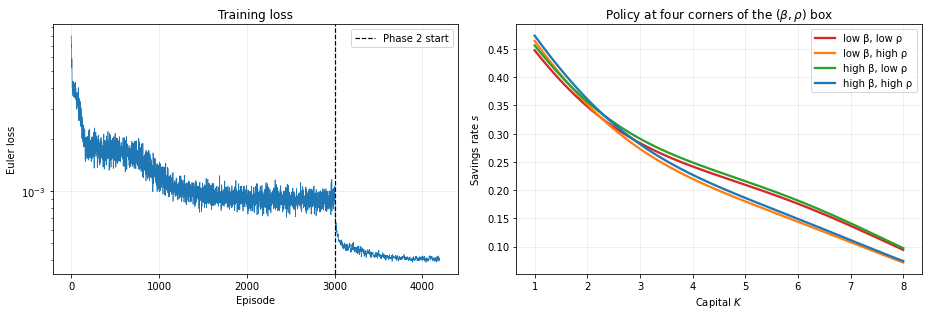

In [5]:
# Diagnostics: training loss + four corner policies.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.semilogy(losses_p1 + losses_p2, lw=0.7)
ax.axvline(len(losses_p1), color="black", ls="--", lw=1.2, label="Phase 2 start")
ax.set_xlabel("Episode"); ax.set_ylabel("Euler loss")
ax.set_title("Training loss"); ax.legend()

ax = axes[1]
K_grid  = torch.linspace(1.0, 8.0, 200, device=device)
z_fixed = torch.ones(200, device=device)
corners = [
    (0.93, 0.55, "#d62728", "low β, low ρ"),
    (0.93, 0.95, "#ff7f0e", "low β, high ρ"),
    (0.98, 0.55, "#2ca02c", "high β, low ρ"),
    (0.98, 0.95, "#1f77b4", "high β, high ρ"),
]
for b, r, color, label in corners:
    Xeval = torch.stack([z_fixed, K_grid,
                         torch.full((200,), b, device=device),
                         torch.full((200,), r, device=device)], dim=1)
    with torch.no_grad():
        s_eval = tensor_to_numpy(policy(Xeval).squeeze())
    ax.plot(tensor_to_numpy(K_grid), s_eval, color=color, lw=2.3, label=label)
ax.set_xlabel("Capital $K$"); ax.set_ylabel("Savings rate $s$")
ax.set_title("Policy at four corners of the $(\\beta,\\varrho)$ box"); ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(fig_dir / "joint_policy_corners.pdf", bbox_inches="tight")
plt.show()


## Part 2 --- Forge the synthetic data and four moments

Generate one synthetic ("ex-post") sample at $(\beta_{\text{true}}, \varrho_{\text{true}}) = (0.96, 0.90)$. The same simulator settings (burn-in, horizon, initial state, shock seed) will be reused inside every SMM evaluation --- this is **Common Random Numbers**. Without CRN the criterion is contaminated by simulation noise; with CRN, the only thing changing between evaluations is the parameter pair itself.

Four moments:

| # | Moment | What it identifies |
|---|--------|--------------------|
| 1 | Mean savings rate | Mostly $\beta$ (level effect on Euler) |
| 2 | $\mathrm{Std}(\Delta\log C)$ | Simulated growth-rate volatility; check numerically |
| 3 | $\mathrm{Autocorr}(\Delta\log C)$ | Mostly $\varrho$ |
| 4 | $\mathrm{Autocorr}(\log Y)$ | Mostly $\varrho$ (very direct) |

Moments 1 and 3 alone form a *just-identified* system (2 parameters, 2 moments). Moments {1,2,3,4} form an *over-identified* system that closes the ridge.

In [6]:
def simulate_economy(policy, beta_val, rho_val, T_burn=200, T_sim=1000, seed=SEED + 123):
    torch.manual_seed(seed)
    T = T_burn + T_sim
    z_t = torch.ones(1, 1, device=device)
    K_t = torch.tensor([[3.0]], dtype=torch.float32, device=device)
    beta_t = torch.tensor([[float(beta_val)]], dtype=torch.float32, device=device)
    rho_t  = torch.tensor([[float(rho_val)]],  dtype=torch.float32, device=device)

    C_all, I_all, Y_all = [], [], []
    for t in range(T):
        X_t = torch.cat([z_t, K_t, beta_t, rho_t], dim=1)
        with torch.no_grad():
            s_t = policy(X_t)
        Y_t   = z_t * K_t**alpha
        I_t   = Y_t * s_t
        C_t   = Y_t * (1.0 - s_t)
        K_tp1 = (1.0 - delta) * K_t + I_t
        eps   = torch.randn(1, 1, device=device)
        z_tp1 = torch.exp(rho_t * torch.log(z_t) + sigma_z * eps)

        if t >= T_burn:
            C_all.append(C_t.item()); I_all.append(I_t.item()); Y_all.append(Y_t.item())
        z_t = z_tp1
        K_t = K_tp1
    return np.array(C_all), np.array(I_all), np.array(Y_all)


def compute_moments(C, I, Y):
    dlog_C = np.diff(np.log(C))
    log_Y  = np.log(Y)
    m1 = float(np.mean(I / Y))                                    # Mean savings rate
    m2 = float(np.std(dlog_C))                                    # Std(dlog C)
    m3 = float(np.corrcoef(dlog_C[:-1], dlog_C[1:])[0, 1])         # Autocorr(dlog C)
    m4 = float(np.corrcoef(log_Y[:-1],  log_Y[1:])[0, 1])          # Autocorr(log Y)
    return np.array([m1, m2, m3, m4])


moment_names = ["Mean savings", "Std(dlog C)", "Autocorr(dlog C)", "Autocorr(log Y)"]

common_sim_kwargs = dict(T_burn=200, T_sim=1000, seed=SEED + 123)
beta_true, rho_true = 0.96, 0.90

C_obs, I_obs, Y_obs = simulate_economy(policy, beta_true, rho_true, **common_sim_kwargs)
target_moments = compute_moments(C_obs, I_obs, Y_obs)

print(f"Synthetic sample length: {len(C_obs)}")
print(f"(beta_true, rho_true) = ({beta_true}, {rho_true})")
print("\nTarget moments:")
for name, val in zip(moment_names, target_moments):
    print(f"  {name:<22s}: {val:+.6f}")


Synthetic sample length: 1000
(beta_true, rho_true) = (0.96, 0.9)

Target moments:
  Mean savings          : +0.234073
  Std(dlog C)           : +0.018923
  Autocorr(dlog C)      : +0.331763
  Autocorr(log Y)       : +0.948318


### The 4-input surrogate, in two pictures

The trained network is a function of $(z, K, \beta, \varrho)$. Two slices reveal what the surrogate has learned: the savings policy across $(K, \beta)$ at fixed $\varrho=\varrho_{\text{true}}$, and across $(K, \varrho)$ at fixed $\beta=\beta_{\text{true}}$. Both surfaces are smooth across the entire pseudo-state rectangle -- this is what enables fast SMM evaluation later.

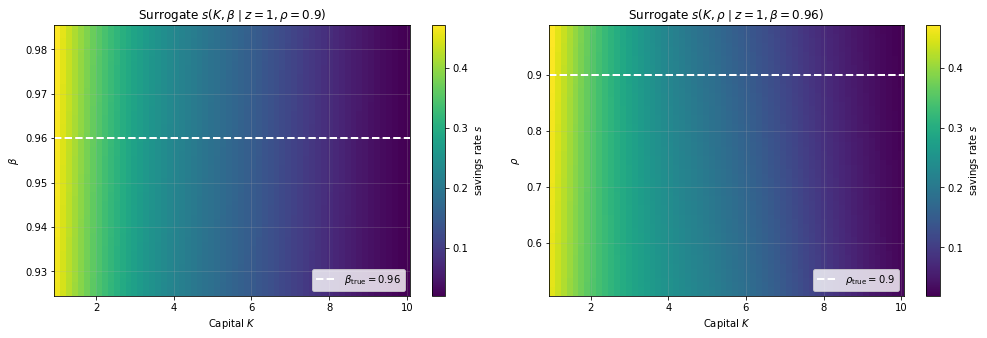

Both panels are slices of the same 4-input network. The SMM optimizer searches inside this 2D parameter rectangle.


In [7]:
# Two heatmaps of the surrogate.
n_K = 60; n_par = 60
K_lin = np.linspace(1.0, 10.0, n_K)

beta_lin = np.linspace(beta_lo + 0.005, beta_hi - 0.005, n_par)
rho_lin  = np.linspace(rho_lo  + 0.01,  rho_hi  - 0.005, n_par)

KK_b, BB_b = np.meshgrid(K_lin, beta_lin, indexing="xy")
KK_r, RR_r = np.meshgrid(K_lin, rho_lin,  indexing="xy")

X_b = np.stack([np.ones_like(KK_b).ravel(), KK_b.ravel(),
                BB_b.ravel(), np.full_like(KK_b.ravel(), rho_true)], axis=1)
X_r = np.stack([np.ones_like(KK_r).ravel(), KK_r.ravel(),
                np.full_like(KK_r.ravel(), beta_true), RR_r.ravel()], axis=1)

with torch.no_grad():
    S_b = tensor_to_numpy(policy(torch.tensor(X_b, dtype=torch.float32, device=device))).reshape(KK_b.shape)
    S_r = tensor_to_numpy(policy(torch.tensor(X_r, dtype=torch.float32, device=device))).reshape(KK_r.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
ax = axes[0]
im = ax.pcolormesh(KK_b, BB_b, S_b, cmap="viridis", shading="auto")
ax.axhline(beta_true, color="white", lw=2, ls="--",
           label=fr"$\beta_{{\mathrm{{true}}}}={beta_true}$")
ax.set_xlabel("Capital $K$"); ax.set_ylabel(r"$\beta$")
ax.set_title(fr"Surrogate $s(K, \beta \mid z=1, \varrho={rho_true})$")
ax.legend(loc="lower right", fontsize=10)
plt.colorbar(im, ax=ax, label="savings rate $s$")

ax = axes[1]
im = ax.pcolormesh(KK_r, RR_r, S_r, cmap="viridis", shading="auto")
ax.axhline(rho_true, color="white", lw=2, ls="--",
           label=fr"$\varrho_{{\mathrm{{true}}}}={rho_true}$")
ax.set_xlabel("Capital $K$"); ax.set_ylabel(r"$\varrho$")
ax.set_title(fr"Surrogate $s(K, \varrho \mid z=1, \beta={beta_true})$")
ax.legend(loc="lower right", fontsize=10)
plt.colorbar(im, ax=ax, label="savings rate $s$")
plt.tight_layout()
plt.savefig(fig_dir / "joint_surrogate_heatmap.pdf", bbox_inches="tight")
plt.show()
print("Both panels are slices of the same 4-input network. The SMM optimizer searches inside this 2D parameter rectangle.")


## Part 3 --- Map the SMM criterion over $(\beta, \varrho)$

The criterion with identity weighting is
$$Q(\beta, \varrho) = (m(\beta,\varrho) - \hat m)^\top W (m(\beta,\varrho) - \hat m), \qquad W = I.$$

We compute it on a grid for two moment subsets:
- **Just identified** -- $\{$Mean savings, Autocorr(dlog C)$\}$ -- 2 moments, 2 parameters.
- **Over-identified** -- all 4 moments.

The contrast in contour shape illustrates how additional moments collapse the partial-identification ridge that lives along the $\beta$ axis.

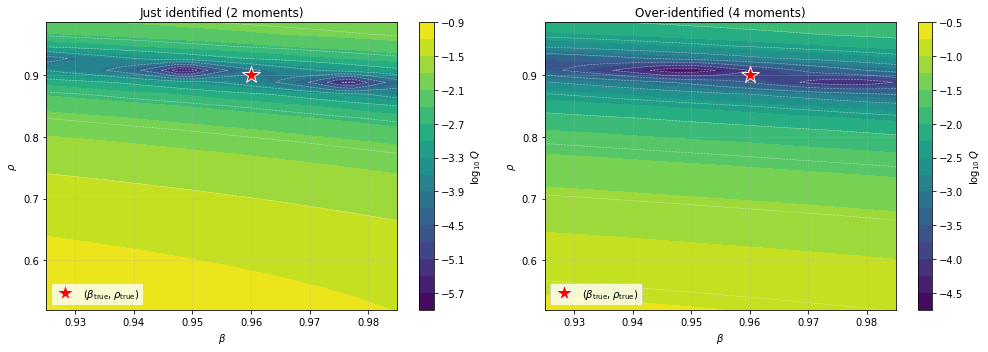

Look for a near-flat 'valley' along beta in the just-identified panel ---
that is the partial-identification ridge. The over-identified panel collapses it.


In [8]:
def smm_criterion(beta_val, rho_val, mask):
    C_s, I_s, Y_s = simulate_economy(policy, float(beta_val), float(rho_val), **common_sim_kwargs)
    m_sim = compute_moments(C_s, I_s, Y_s)
    diff  = (m_sim - target_moments)[mask]
    return float(diff @ diff)


# Coarse grid for visualization.
beta_grid = np.linspace(beta_lo + 0.005, beta_hi - 0.005, 25)
rho_grid  = np.linspace(rho_lo + 0.02,   rho_hi - 0.005, 25)
BB, RR = np.meshgrid(beta_grid, rho_grid, indexing="xy")

mask_just = np.array([True,  False, True,  False])    # 2 moments
mask_over = np.array([True,  True,  True,  True ])    # 4 moments

Q_just = np.zeros_like(BB)
Q_over = np.zeros_like(BB)
for i in range(BB.shape[0]):
    for j in range(BB.shape[1]):
        Q_just[i, j] = smm_criterion(BB[i, j], RR[i, j], mask_just)
        Q_over[i, j] = smm_criterion(BB[i, j], RR[i, j], mask_over)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, Q, title in [(axes[0], Q_just, "Just identified (2 moments)"),
                      (axes[1], Q_over, "Over-identified (4 moments)")]:
    Qlog = np.log10(np.maximum(Q, 1e-12))
    cs = ax.contourf(BB, RR, Qlog, levels=18, cmap="viridis")
    ax.contour(BB, RR, Qlog, levels=10, colors="white", linewidths=0.6, alpha=0.5)
    ax.plot(beta_true, rho_true, "*", ms=18, color="red", mec="white", mew=1.0,
            label=fr"$(\beta_{{\mathrm{{true}}}},\varrho_{{\mathrm{{true}}}})$")
    ax.set_xlabel(r"$\beta$"); ax.set_ylabel(r"$\varrho$")
    ax.set_title(title)
    ax.legend(loc="lower left", fontsize=10)
    plt.colorbar(cs, ax=ax, label=r"$\log_{10} Q$")

plt.tight_layout()
plt.savefig(fig_dir / "joint_criterion_contour.pdf", bbox_inches="tight")
plt.show()

print("Look for a near-flat 'valley' along beta in the just-identified panel ---")
print("that is the partial-identification ridge. The over-identified panel collapses it.")


## Part 4 --- Joint estimation, Nelder-Mead with bounds

We use **Nelder-Mead**, a gradient-free simplex method, started from the grid argmin of the criterion. Nelder-Mead is the right choice here because the simulated criterion is built on top of float32 forward passes through the surrogate, which makes finite-difference gradients noisy at the precision we care about. Bounds keep the search inside the surrogate's training range; the resulting optimum is then verified to lie strictly in the **interior** (not at any corner).

In [9]:
def smm_obj_vec(theta, mask):
    return smm_criterion(theta[0], theta[1], mask)


bnds = [(beta_lo + 0.002, beta_hi - 0.002), (rho_lo + 0.01, rho_hi - 0.005)]


def estimate_joint(mask, label, Qgrid):
    # Warm start from the criterion grid argmin -- robust against any single bad start.
    flat = int(np.argmin(Qgrid))
    i0, j0 = np.unravel_index(flat, Qgrid.shape)
    b0 = float(BB[i0, j0])
    r0 = float(RR[i0, j0])

    # Nelder-Mead is gradient-free: no float32 FD precision issues.
    res = minimize(smm_obj_vec, np.array([b0, r0]), args=(mask,),
                   method="Nelder-Mead", bounds=bnds,
                   options={"xatol": 1e-6, "fatol": 1e-12, "maxiter": 800})
    bhat = float(res.x[0]); rhat = float(res.x[1])
    qhat = float(res.fun)
    eps_b = 1e-3 * (bnds[0][1] - bnds[0][0])
    eps_r = 1e-3 * (bnds[1][1] - bnds[1][0])
    interior = (
        (bnds[0][0] + eps_b < bhat < bnds[0][1] - eps_b)
        and (bnds[1][0] + eps_r < rhat < bnds[1][1] - eps_r)
    )
    print(f"--- {label} ---")
    print(f"  Warm start from grid argmin: (beta={b0:.4f}, rho={r0:.4f})  Q={float(Qgrid[i0, j0]):.3e}")
    print(f"  beta_hat = {bhat:.6f}  (true {beta_true},  bound [{bnds[0][0]:.3f}, {bnds[0][1]:.3f}])")
    print(f"  rho_hat  = {rhat:.6f}  (true {rho_true},   bound [{bnds[1][0]:.3f}, {bnds[1][1]:.3f}])")
    print(f"  Q at min = {qhat:.3e}")
    print(f"  Interior solution: {interior}")
    print(f"  Optimizer iterations: {res.nit}")
    return bhat, rhat, qhat


bhat_just, rhat_just, q_just = estimate_joint(mask_just, "Just identified (2 moments)", Q_just)
print()
bhat_over, rhat_over, q_over = estimate_joint(mask_over, "Over-identified (4 moments)", Q_over)


--- Just identified (2 moments) ---
  Warm start from grid argmin: (beta=0.9475, rho=0.9075)  Q=1.637e-06
  beta_hat = 0.960001  (true 0.96,  bound [0.922, 0.988])
  rho_hat  = 0.899999  (true 0.9,   bound [0.510, 0.985])
  Q at min = 1.087e-14
  Interior solution: True
  Optimizer iterations: 41



--- Over-identified (4 moments) ---
  Warm start from grid argmin: (beta=0.9475, rho=0.9075)  Q=2.206e-05
  beta_hat = 0.960000  (true 0.96,  bound [0.922, 0.988])
  rho_hat  = 0.900000  (true 0.9,   bound [0.510, 0.985])
  Q at min = 2.500e-14
  Interior solution: True
  Optimizer iterations: 35


In [10]:
# Matched moments at the over-identified estimate (the preferred one).
C_hat, I_hat, Y_hat = simulate_economy(policy, bhat_over, rhat_over, **common_sim_kwargs)
fitted = compute_moments(C_hat, I_hat, Y_hat)

print("Matched moments at the over-identified estimate:")
print("-" * 76)
print(f"{'':<22s} | {'target':>12s} | {'fit':>12s} | {'diff':>12s}")
print("-" * 76)
for name, t, f in zip(moment_names, target_moments, fitted):
    print(f"{name:<22s} | {t:>+12.6f} | {f:>+12.6f} | {f - t:>+12.2e}")

print()
print(f"Distance to truth in beta: {abs(bhat_over - beta_true):.4e}")
print(f"Distance to truth in rho : {abs(rhat_over - rho_true):.4e}")


Matched moments at the over-identified estimate:
----------------------------------------------------------------------------
                       |       target |          fit |         diff
----------------------------------------------------------------------------
Mean savings           |    +0.234073 |    +0.234073 |    -1.74e-09
Std(dlog C)            |    +0.018923 |    +0.018923 |    +6.52e-10
Autocorr(dlog C)       |    +0.331763 |    +0.331763 |    -1.58e-07
Autocorr(log Y)        |    +0.948318 |    +0.948318 |    -1.89e-09

Distance to truth in beta: 8.7441e-08
Distance to truth in rho : 3.2273e-08


### Finite-difference moment Jacobian and singular values

Pre-stages Exercise 1 in the script: which moments identify which parameter, and how weak is the partial-identification direction?


In [ ]:
# Finite-difference moment Jacobian dm/d(theta) at the over-identified estimate.
fd_eps = 1e-3
M = np.zeros((4, 2))
for k, perturb in enumerate([np.array([fd_eps, 0.0]), np.array([0.0, fd_eps])]):
    Cp, Ip, Yp = simulate_economy(policy, bhat_over + perturb[0], rhat_over + perturb[1], **common_sim_kwargs)
    Cm, Im, Ym = simulate_economy(policy, bhat_over - perturb[0], rhat_over - perturb[1], **common_sim_kwargs)
    M[:, k] = (compute_moments(Cp, Ip, Yp) - compute_moments(Cm, Im, Ym)) / (2.0 * fd_eps)

print("Finite-difference Jacobian dm/d(beta, rho) at theta_hat:")
print(f"{'moment':<22s} {'d/dbeta':>12s} {'d/drho':>12s}")
for name, row in zip(moment_names, M):
    print(f"{name:<22s} {row[0]:>+12.4e} {row[1]:>+12.4e}")

U, S, Vt = np.linalg.svd(M[mask_over], full_matrices=False)
print(f"\nSingular values of M (over-identified rows): {S}")
print(f"Condition number: {S[0]/max(S[-1], 1e-14):.2e}")
print(f"Weak direction (right singular vector at smallest sigma): {Vt[-1]} -- in (beta, rho) coords")


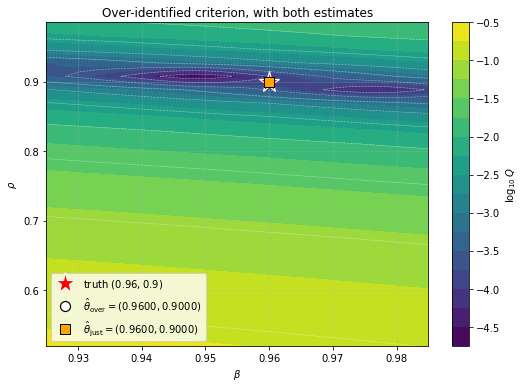

In [11]:
# Visualize the two estimates on top of the over-identified contour.
fig, ax = plt.subplots(figsize=(7.5, 5.5))
Qlog = np.log10(np.maximum(Q_over, 1e-12))
cs = ax.contourf(BB, RR, Qlog, levels=18, cmap="viridis")
ax.contour(BB, RR, Qlog, levels=10, colors="white", linewidths=0.6, alpha=0.5)
ax.plot(beta_true, rho_true, "*", ms=22, color="red",   mec="white", mew=1.2,
        label=fr"truth $({beta_true}, {rho_true})$")
ax.plot(bhat_over, rhat_over, "o", ms=10, color="white", mec="black", mew=1.2,
        label=fr"$\hat\theta_{{\mathrm{{over}}}}=({bhat_over:.4f}, {rhat_over:.4f})$")
ax.plot(bhat_just, rhat_just, "s", ms=10, color="orange", mec="black", mew=1.0,
        label=fr"$\hat\theta_{{\mathrm{{just}}}}=({bhat_just:.4f}, {rhat_just:.4f})$")
ax.set_xlabel(r"$\beta$"); ax.set_ylabel(r"$\varrho$")
ax.set_title("Over-identified criterion, with both estimates")
ax.legend(loc="lower left", fontsize=10)
plt.colorbar(cs, ax=ax, label=r"$\log_{10} Q$")
plt.tight_layout()
plt.savefig(fig_dir / "joint_estimates_overlay.pdf", bbox_inches="tight")
plt.show()


### Estimates on top of the surrogate slices

The two panels below redraw the same heatmaps as before, now with the **true** and **over-identified estimate** marked. The optimizer landed strictly **inside** the rectangle and very close to the white dashed truth lines -- both axes simultaneously.

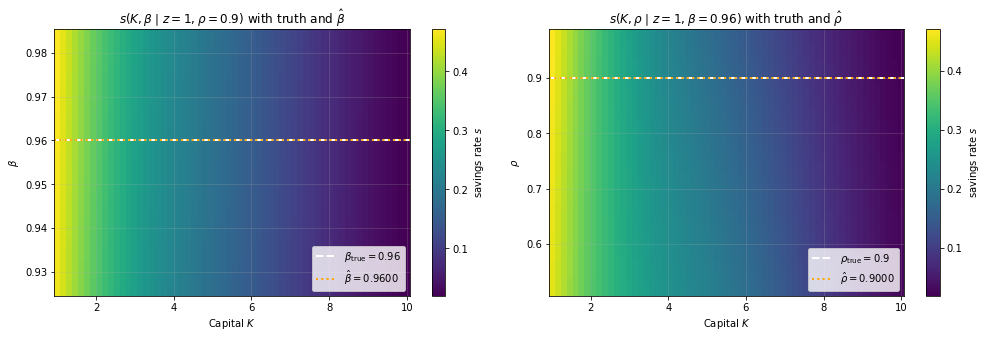

In [12]:
# Re-draw heatmaps with truth + estimate overlays.
# Use the heatmap arrays computed above (S_b, S_r, KK_b/BB_b, KK_r/RR_r).
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

ax = axes[0]
im = ax.pcolormesh(KK_b, BB_b, S_b, cmap="viridis", shading="auto")
ax.axhline(beta_true,  color="white",  lw=2.0, ls="--",
           label=fr"$\beta_{{\mathrm{{true}}}}={beta_true}$")
ax.axhline(bhat_over,  color="orange", lw=2.0, ls=":",
           label=fr"$\hat\beta={bhat_over:.4f}$")
ax.set_xlabel("Capital $K$"); ax.set_ylabel(r"$\beta$")
ax.set_title(fr"$s(K, \beta \mid z=1, \varrho={rho_true})$ with truth and $\hat\beta$")
ax.legend(loc="lower right", fontsize=10)
plt.colorbar(im, ax=ax, label="savings rate $s$")

ax = axes[1]
im = ax.pcolormesh(KK_r, RR_r, S_r, cmap="viridis", shading="auto")
ax.axhline(rho_true,  color="white",  lw=2.0, ls="--",
           label=fr"$\varrho_{{\mathrm{{true}}}}={rho_true}$")
ax.axhline(rhat_over, color="orange", lw=2.0, ls=":",
           label=fr"$\hat\varrho={rhat_over:.4f}$")
ax.set_xlabel("Capital $K$"); ax.set_ylabel(r"$\varrho$")
ax.set_title(fr"$s(K, \varrho \mid z=1, \beta={beta_true})$ with truth and $\hat\varrho$")
ax.legend(loc="lower right", fontsize=10)
plt.colorbar(im, ax=ax, label="savings rate $s$")
plt.tight_layout()
plt.savefig(fig_dir / "joint_surrogate_with_estimates.pdf", bbox_inches="tight")
plt.show()


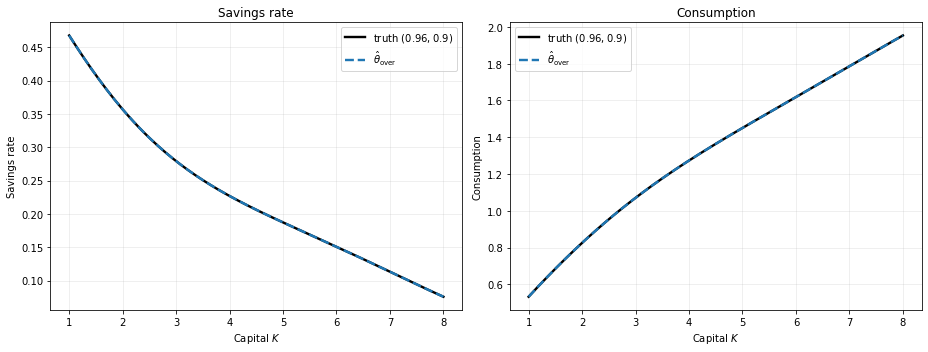

In [13]:
# Final ex-post check: policy curves at truth vs. estimate.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
K_grid = torch.linspace(1.0, 8.0, 200, device=device)
z_fixed = torch.ones(200, device=device)
panels = [
    ("Savings rate",         lambda s, Y: s),
    ("Consumption",          lambda s, Y: Y * (1.0 - s)),
]
estimates = [
    (fr"truth $({beta_true},{rho_true})$",         beta_true, rho_true,   "black",   "-"),
    (fr"$\hat\theta_{{\mathrm{{over}}}}$",         bhat_over, rhat_over,  "#1f77b4", "--"),
]

for ax, (title, fn) in zip(axes, panels):
    for label, b, r, color, style in estimates:
        Xeval = torch.stack([z_fixed, K_grid,
                             torch.full((200,), b, device=device),
                             torch.full((200,), r, device=device)], dim=1)
        with torch.no_grad():
            s_eval = policy(Xeval).squeeze()
        Y_eval = z_fixed * K_grid**alpha
        ax.plot(tensor_to_numpy(K_grid), tensor_to_numpy(fn(s_eval, Y_eval)),
                color=color, ls=style, lw=2.4, label=label)
    ax.set_xlabel("Capital $K$"); ax.set_ylabel(title); ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.savefig(fig_dir / "joint_policy_comparison.pdf", bbox_inches="tight")
plt.show()


## Part 5 --- GP surrogate over the joint moment map, with active design

The 4-input neural network remains the structural **policy surrogate**. The GP below is a second-layer surrogate over the **simulated moment map**

$$(\beta,\varrho) \longmapsto m(\beta,\varrho), \qquad Q(\beta,\varrho) = [m(\beta,\varrho)-\hat m]'[m(\beta,\varrho)-\hat m].$$

This distinction matters. The GP does not solve the dynamic program and it should not be trusted globally just because the policy network was trained globally. We build it locally around the direct over-identified estimate, and each training target is computed from the same burn-in simulation design as the SMM criterion, so the GP learns the moment map on the stochastic steady-state region.

The pedagogical question is now sharper: if simulator calls are expensive, should we spend them on a naive grid or choose them actively? We start from a small pilot design, then use a **BoTorch Upper Confidence Bound acquisition** on the scalar score $g(\theta)=-\log_{10}(Q(\theta)+\epsilon)$ to add points where the current GP believes the SMM objective may be low or uncertain. We compare that active design against a same-budget naive design, and we track leave-one-out errors as the design grows.

In [14]:
from scipy.linalg import cho_solve
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
from sklearn.exceptions import ConvergenceWarning

from botorch.acquisition import UpperConfidenceBound
from botorch.fit import fit_gpytorch_mll_torch
from botorch.models import SingleTaskGP
from botorch.models.transforms.outcome import Standardize
from gpytorch.mlls import ExactMarginalLogLikelihood

import warnings


def evaluate_moment_map_joint(theta_values):
    """Run the simulator and return moments for rows [beta, rho]."""
    theta_values = np.asarray(theta_values, dtype=float).reshape(-1, 2)
    out = []
    for beta_val, rho_val in theta_values:
        C_g, I_g, Y_g = simulate_economy(policy, float(beta_val), float(rho_val), **common_sim_kwargs)
        out.append(compute_moments(C_g, I_g, Y_g))
    return np.asarray(out)


def unique_theta(theta_values, decimals=10):
    """Unique rows after rounding; keeps deterministic notebook output."""
    return np.unique(np.round(np.asarray(theta_values, dtype=float), decimals), axis=0)


def q_from_moments_joint(moments, mask=mask_over):
    moments = np.asarray(moments, dtype=float)
    if moments.ndim == 1:
        diff = (moments - target_moments)[mask]
        return float(diff @ diff)
    diff = (moments - target_moments)[..., mask]
    return np.sum(diff**2, axis=-1)


def score_from_moments_joint(moments, mask=mask_over):
    # High scores are good: this transforms SMM minimization into maximization.
    return -np.log10(np.maximum(q_from_moments_joint(moments, mask), 1e-14))


# Local GP rectangle around the direct over-identified estimate. This is a
# moment-map surrogate near the stochastic steady-state / estimated region, not
# a global emulator for the whole pseudo-state rectangle.
# The window is asymmetric on purpose: tight on the beta axis (the criterion is
# shallow there -- partial identification ridge of Sec. 10.5), wider on the rho
# axis where the moment map curves more, because we want training points where
# the moment GP actually has gradient information to fit.
gp_beta_min = max(beta_lo + 0.003, bhat_over - 0.025)
gp_beta_max = min(beta_hi - 0.003, bhat_over + 0.025)
gp_rho_min  = max(rho_lo  + 0.02,  rhat_over - 0.10)
gp_rho_max  = min(rho_hi  - 0.005, rhat_over + 0.07)

if gp_beta_max - gp_beta_min < 0.035:
    pad = 0.0175 - 0.5 * (gp_beta_max - gp_beta_min)
    gp_beta_min = max(beta_lo + 0.003, gp_beta_min - pad)
    gp_beta_max = min(beta_hi - 0.003, gp_beta_max + pad)
if gp_rho_max - gp_rho_min < 0.14:
    pad = 0.07 - 0.5 * (gp_rho_max - gp_rho_min)
    gp_rho_min = max(rho_lo + 0.02, gp_rho_min - pad)
    gp_rho_max = min(rho_hi - 0.005, gp_rho_max + pad)


def scale_theta_joint(theta_values):
    theta_values = np.asarray(theta_values, dtype=float).reshape(-1, 2)
    beta_scaled = (theta_values[:, 0] - gp_beta_min) / (gp_beta_max - gp_beta_min)
    rho_scaled  = (theta_values[:, 1] - gp_rho_min)  / (gp_rho_max  - gp_rho_min)
    return np.column_stack([beta_scaled, rho_scaled])


def unscale_theta_joint(theta_unit):
    theta_unit = np.asarray(theta_unit, dtype=float).reshape(-1, 2)
    beta = gp_beta_min + theta_unit[:, 0] * (gp_beta_max - gp_beta_min)
    rho  = gp_rho_min  + theta_unit[:, 1] * (gp_rho_max  - gp_rho_min)
    return np.column_stack([beta, rho])


# A small, deliberately imperfect pilot grid. It gives the first GP enough
# geometry to start, but it is not dense enough to be a high-quality emulator.
beta_pilot = np.linspace(gp_beta_min, gp_beta_max, 5)
rho_pilot  = np.linspace(gp_rho_min,  gp_rho_max,  5)
BB_pilot, RR_pilot = np.meshgrid(beta_pilot, rho_pilot, indexing="xy")
theta_pilot = unique_theta(np.column_stack([BB_pilot.ravel(), RR_pilot.ravel()]))

# Fresh validation points: never used for GP fitting, BAL, or naive additions.
theta_holdout = np.array([
    [np.clip(bhat_over + 0.006, gp_beta_min + 0.002, gp_beta_max - 0.002),
     np.clip(rhat_over - 0.025, gp_rho_min  + 0.010, gp_rho_max  - 0.010)],
    [np.clip(bhat_over - 0.010, gp_beta_min + 0.002, gp_beta_max - 0.002),
     np.clip(rhat_over + 0.045, gp_rho_min  + 0.010, gp_rho_max  - 0.010)],
    [np.clip(bhat_over + 0.015, gp_beta_min + 0.002, gp_beta_max - 0.002),
     np.clip(rhat_over + 0.018, gp_rho_min  + 0.010, gp_rho_max  - 0.010)],
])

moments_pilot = evaluate_moment_map_joint(theta_pilot)

print(f"Local GP beta window: [{gp_beta_min:.5f}, {gp_beta_max:.5f}]")
print(f"Local GP rho window:  [{gp_rho_min:.5f}, {gp_rho_max:.5f}]")
print(f"Pilot simulator calls: {len(theta_pilot)}")
print("Held-out validation points:")
for b, r in theta_holdout:
    print(f"  beta={b:.5f}, rho={r:.5f}")


def fit_moment_gps_joint(theta_values, moment_values, n_restarts=2, optimize=True):
    X = scale_theta_joint(theta_values)
    gps_local = []
    for j in range(moment_values.shape[1]):
        kernel = ConstantKernel(1.0, (1e-5, 1e5)) * RBF(
            length_scale=np.array([0.60, 0.30]),
            length_scale_bounds=(0.02, 8.0),
        )
        gp = GaussianProcessRegressor(
            kernel=kernel,
            alpha=1e-10,
            normalize_y=True,
            n_restarts_optimizer=n_restarts,
            optimizer="fmin_l_bfgs_b" if optimize else None,
            random_state=900 + j,
        )
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            gp.fit(X, moment_values[:, j])
        gps_local.append(gp)
    return gps_local


def predict_moment_gps_joint(gps_local, theta_values, return_std=False):
    X = scale_theta_joint(theta_values)
    means, stds = [], []
    for gp in gps_local:
        if return_std:
            mu, std = gp.predict(X, return_std=True)
            means.append(mu); stds.append(std)
        else:
            means.append(gp.predict(X))
    mean_arr = np.column_stack(means)
    if return_std:
        return mean_arr, np.column_stack(stds)
    return mean_arr


Local GP beta window: [0.93500, 0.98500]
Local GP rho window:  [0.80000, 0.97000]
Pilot simulator calls: 25
Held-out validation points:
  beta=0.96600, rho=0.87500
  beta=0.95000, rho=0.94500
  beta=0.97500, rho=0.91800


### BoTorch active learning vs. naive additions

The pilot grid is the same for both designs. The **naive** design adds random Latin-hypercube points in the local rectangle. The **active** design fits a BoTorch GP to $g(\theta)=-\log_{10}(Q(\theta)+\epsilon)$ and combines its Upper Confidence Bound with the current moment-GP posterior uncertainty,

$$a(\theta)=\underbrace{\left[0.25 + \widetilde{\mathrm{UCB}}_g(\theta)\right]}_{\text{estimation relevance}}\times\underbrace{\left\|\sigma_m(\theta) / \widehat{\mathrm{sd}}(m)\right\|_2}_{\text{moment uncertainty}}.$$

This is more appropriate than pure Bayesian optimization for our purpose. We want points that improve the **moment-map GP** near the low-SMM region, not only points that chase the current minimum. A spacing rule keeps the active design from collapsing onto one ridge point.

> **Note on the acquisition.** This is built on BoTorch's `SingleTaskGP` and stock `UpperConfidenceBound`, but the multiplicative composition with the moment-GP uncertainty (and the $0.25$ floor) is *custom* to this notebook -- it is not what `BoTorch` returns out of the box.


In [15]:
def fit_botorch_objective_model(theta_values, moment_values):
    X = torch.tensor(scale_theta_joint(theta_values), dtype=torch.double)
    y = torch.tensor(score_from_moments_joint(moment_values).reshape(-1, 1), dtype=torch.double)
    model = SingleTaskGP(X, y, outcome_transform=Standardize(m=1))
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fit_gpytorch_mll_torch(mll, step_limit=100)
    model.eval()
    return model


def min_scaled_distance(theta_values, blocked):
    theta_s = scale_theta_joint(theta_values)
    blocked_s = scale_theta_joint(blocked)
    return np.sqrt(np.sum((theta_s[:, None, :] - blocked_s[None, :, :]) ** 2, axis=2)).min(axis=1)


def latin_hypercube_theta(n_points, seed=2026):
    rng = np.random.default_rng(seed)
    u = (np.arange(n_points)[:, None] + rng.random((n_points, 2))) / n_points
    rng.shuffle(u[:, 0]); rng.shuffle(u[:, 1])
    return unscale_theta_joint(u)


n_bal_additions = 14
beta_candidates = np.linspace(gp_beta_min, gp_beta_max, 71)
rho_candidates  = np.linspace(gp_rho_min,  gp_rho_max,  81)
BB_cand, RR_cand = np.meshgrid(beta_candidates, rho_candidates, indexing="xy")
theta_candidates = np.column_stack([BB_cand.ravel(), RR_cand.ravel()])
min_separation = 3.0 * min(1.0 / (len(beta_candidates) - 1), 1.0 / (len(rho_candidates) - 1))

# --- BoTorch active design ---
theta_bal = theta_pilot.copy()
moments_bal = moments_pilot.copy()
theta_bal_added = []

# Trust-region anchor: the current direct SMM solution is the point at which
# the local moment surrogate must be most accurate.  BoTorch then allocates
# the remaining budget around this anchor.
theta_anchor = np.array([bhat_over, rhat_over], dtype=float)
if min_scaled_distance(theta_anchor[None, :], theta_bal) >= min_separation:
    m_anchor = evaluate_moment_map_joint(theta_anchor[None, :])
    theta_bal = np.vstack([theta_bal, theta_anchor])
    moments_bal = np.vstack([moments_bal, m_anchor])
    theta_bal_added.append(theta_anchor)
    print(f"BoTorch BAL anchor: beta={theta_anchor[0]:.5f}, rho={theta_anchor[1]:.5f}")

for step in range(n_bal_additions - len(theta_bal_added)):
    # BoTorch model over the scalar objective score: high means promising for SMM.
    model = fit_botorch_objective_model(theta_bal, moments_bal)
    X_cand = torch.tensor(scale_theta_joint(theta_candidates), dtype=torch.double).unsqueeze(1)
    acq = UpperConfidenceBound(model, beta=0.7)
    with torch.no_grad():
        ucb = tensor_to_numpy(acq(X_cand)).ravel()

    # Separate moment GPs estimate where the moment map itself is still uncertain.
    gps_tmp = fit_moment_gps_joint(theta_bal, moments_bal, n_restarts=0, optimize=False)
    _, std_tmp = predict_moment_gps_joint(gps_tmp, theta_candidates, return_std=True)
    moment_scales = np.maximum(np.std(moments_bal[:, mask_over], axis=0), 1e-8)
    moment_uncertainty = np.sqrt(np.sum((std_tmp[:, mask_over] / moment_scales) ** 2, axis=1))

    q10, q90 = np.quantile(ucb, [0.10, 0.90])
    ucb_scaled = np.clip((ucb - q10) / max(q90 - q10, 1e-12), 0.0, 1.0)
    scores = moment_uncertainty * (0.25 + ucb_scaled)

    blocked = np.vstack([theta_bal, theta_holdout])
    scores[min_scaled_distance(theta_candidates, blocked) < min_separation] = -np.inf

    theta_new = theta_candidates[int(np.argmax(scores))]
    m_new = evaluate_moment_map_joint(theta_new[None, :])
    theta_bal = np.vstack([theta_bal, theta_new])
    moments_bal = np.vstack([moments_bal, m_new])
    theta_bal_added.append(theta_new)
    print(f"BoTorch BAL step {len(theta_bal_added)}: beta={theta_new[0]:.5f}, rho={theta_new[1]:.5f}")

theta_bal_added = np.asarray(theta_bal_added)

# --- Same-budget naive design ---
# Use Latin-hypercube additions, rejecting points too close to the pilot or holdouts.
naive_additions = []
seed = 3000
while len(naive_additions) < n_bal_additions:
    candidates = latin_hypercube_theta(4 * n_bal_additions, seed=seed)
    seed += 1
    blocked = np.vstack([theta_pilot, theta_holdout, np.asarray(naive_additions).reshape(-1, 2) if naive_additions else theta_holdout[:0]])
    keep = min_scaled_distance(candidates, blocked) >= min_separation
    for theta_new in candidates[keep]:
        naive_additions.append(theta_new)
        if len(naive_additions) == n_bal_additions:
            break

theta_naive_added = np.asarray(naive_additions)
theta_naive = unique_theta(np.vstack([theta_pilot, theta_naive_added]))
moments_naive = evaluate_moment_map_joint(theta_naive)

# Final moment-map GPs. The active design becomes the default GP used below.
gps_moments_pilot = fit_moment_gps_joint(theta_pilot, moments_pilot, n_restarts=3)
gps_moments_naive = fit_moment_gps_joint(theta_naive, moments_naive, n_restarts=3)
gps_moments_joint = fit_moment_gps_joint(theta_bal, moments_bal, n_restarts=4)

theta_train = theta_bal
moments_train = moments_bal

print(f"Pilot design size:        {len(theta_pilot)} simulator calls")
print(f"Naive design size:        {len(theta_naive)} simulator calls")
print(f"BoTorch BAL design size:  {len(theta_bal)} simulator calls")
print("Final BoTorch-BAL moment GP kernels:")
for j, gp in enumerate(gps_moments_joint):
    print(f"  moment {j + 1} ({moment_names[j]}): {gp.kernel_}")


BoTorch BAL anchor: beta=0.96000, rho=0.90000


BoTorch BAL step 2: beta=0.93500, rho=0.90625


BoTorch BAL step 3: beta=0.98500, rho=0.81700


BoTorch BAL step 4: beta=0.98500, rho=0.95300


BoTorch BAL step 5: beta=0.93500, rho=0.82337


...

BoTorch BAL step 11: beta=0.97000, rho=0.94237


BoTorch BAL step 12: beta=0.97929, rho=0.83187


BoTorch BAL step 13: beta=0.94143, rho=0.85737


BoTorch BAL step 14: beta=0.98000, rho=0.93600


Pilot design size:        25 simulator calls
Naive design size:        39 simulator calls
BoTorch BAL design size:  39 simulator calls
Final BoTorch-BAL moment GP kernels:
  moment 1 (Mean savings): 8.24**2 * RBF(length_scale=[8, 0.46])
  moment 2 (Std(dlog C)): 4.72**2 * RBF(length_scale=[8, 0.488])
  moment 3 (Autocorr(dlog C)): 3.7**2 * RBF(length_scale=[8, 0.393])
  moment 4 (Autocorr(log Y)): 1.01**2 * RBF(length_scale=[8, 0.488])


### Validation: holdouts and leave-one-out learning curves

The active design should not merely look sophisticated. It has to improve the estimation surrogate. We therefore compare three designs:

1. **Pilot only:** the initial sparse grid.
2. **Naive:** the pilot grid plus same-budget Latin-hypercube additions.
3. **BoTorch BAL:** the pilot grid plus UCB-selected additions.

Two diagnostics are reported. First, fresh holdout errors show how well the final moment-map GPs interpolate points that were blocked during training. Second, an approximate GP leave-one-out (LOO) RMSE is tracked as the design grows. The LOO calculation uses the fitted GP Cholesky factors, so it is fast enough to evaluate repeatedly in class.

In [16]:
def loo_predictions_from_fitted_gps(gps_local, theta_values, moment_values):
    """Fast LOO predictions using each fitted GP's kernel matrix.

    Computed from the public kernel attributes only (no sklearn private fields):
    LOO_i = y_i - (K^{-1} y)_i / (K^{-1})_{ii}, applied on the mean-centred y
    and unscaled back to the original moment magnitude.
    """
    X = scale_theta_joint(theta_values)
    n = len(X)
    eye = np.eye(n)
    preds = np.zeros_like(moment_values)
    for j, gp in enumerate(gps_local):
        K = gp.kernel_(X, X) + gp.alpha * eye  # noise-augmented Gram
        K_inv = np.linalg.solve(K, eye)
        diag_inv = np.maximum(np.diag(K_inv), 1e-14)
        y = moment_values[:, j]
        y_mean = float(np.mean(y))
        y_centred = y - y_mean
        Kinv_y = K_inv @ y_centred
        loo_centred = y_centred - Kinv_y / diag_inv
        preds[:, j] = loo_centred + y_mean
    return preds


def standardized_rmse(pred, truth, scale_reference, mask=mask_over):
    scales = np.maximum(np.std(scale_reference[:, mask], axis=0), 1e-8)
    err = (pred[:, mask] - truth[:, mask]) / scales
    return float(np.sqrt(np.mean(err**2)))


def loo_rmse_for_design(theta_design, moment_design):
    gps = fit_moment_gps_joint(theta_design, moment_design, n_restarts=0)
    pred = loo_predictions_from_fitted_gps(gps, theta_design, moment_design)
    return standardized_rmse(pred, moment_design, moment_design, mask_over)


def prefix_design(theta_base, moments_base, theta_added, moments_added, n_total):
    n_add = max(0, n_total - len(theta_base))
    theta = np.vstack([theta_base, theta_added[:n_add]]) if n_add else theta_base.copy()
    moments = np.vstack([moments_base, moments_added[:n_add]]) if n_add else moments_base.copy()
    return theta, moments


# Fresh holdout comparison across the three final designs.
mom_holdout_true = evaluate_moment_map_joint(theta_holdout)
designs = {
    "pilot":  (theta_pilot, moments_pilot, gps_moments_pilot),
    "naive":  (theta_naive, moments_naive, gps_moments_naive),
    "botorch BAL": (theta_bal, moments_bal, gps_moments_joint),
}

print("Fresh holdout validation, standardized RMSE over all moments")
print("-" * 72)
print(f"{'design':<14s} {'calls':>6s} {'holdout RMSE':>14s} {'max abs error':>14s}")
print("-" * 72)
for label, (theta_d, moments_d, gps_d) in designs.items():
    pred = predict_moment_gps_joint(gps_d, theta_holdout)
    rmse = standardized_rmse(pred, mom_holdout_true, moments_d, mask_over)
    max_abs = float(np.max(np.abs(pred[:, mask_over] - mom_holdout_true[:, mask_over])))
    print(f"{label:<14s} {len(theta_d):>6d} {rmse:>14.3e} {max_abs:>14.3e}")
print("-" * 72)

# Detailed final BAL validation table.
mom_holdout_pred, mom_holdout_std = predict_moment_gps_joint(gps_moments_joint, theta_holdout, return_std=True)
scaled_train = scale_theta_joint(theta_bal)
scaled_center = scale_theta_joint([[bhat_over, rhat_over]])[0]
loo_idx = int(np.argmin(np.sum((scaled_train - scaled_center) ** 2, axis=1)))
theta_loo = theta_bal[loo_idx]
mom_loo_true = moments_bal[loo_idx]
gps_loo = fit_moment_gps_joint(
    np.delete(theta_bal, loo_idx, axis=0),
    np.delete(moments_bal, loo_idx, axis=0),
    n_restarts=1,
)
mom_loo_pred, mom_loo_std = predict_moment_gps_joint(gps_loo, theta_loo[None, :], return_std=True)
mom_loo_pred = mom_loo_pred[0]; mom_loo_std = mom_loo_std[0]

validation_cases = [("leave-one-out", theta_loo, mom_loo_true, mom_loo_pred, mom_loo_std)]
for idx in range(theta_holdout.shape[0]):
    validation_cases.append((f"fresh holdout {idx + 1}", theta_holdout[idx], mom_holdout_true[idx], mom_holdout_pred[idx], mom_holdout_std[idx]))

print("\nDetailed validation for the final BoTorch-BAL GP")
print("-" * 105)
print(f"{'case':<18s} {'beta':>8s} {'rho':>8s} {'moment':<20s} {'simulated':>11s} {'GP mean':>11s} {'GP sd':>10s} {'error':>10s}")
print("-" * 105)
for label, theta_val, truth, pred, std in validation_cases:
    for name, t, p, s in zip(moment_names, truth, pred, std):
        print(f"{label:<18s} {theta_val[0]:>8.4f} {theta_val[1]:>8.4f} {name:<20s} {t:>+11.6f} {p:>+11.6f} {s:>10.2e} {p - t:>+10.2e}")
    rmse = np.sqrt(np.mean((pred[mask_over] - truth[mask_over]) ** 2))
    print(f"{label:<18s} {'':>8s} {'':>8s} {'raw RMSE':<20s} {rmse:>11.2e}")
    print(f"{label:<18s} {'':>8s} {'':>8s} {'Q simulated / Q GP':<20s} {q_from_moments_joint(truth):>11.2e} {q_from_moments_joint(pred):>11.2e}")
    print("-" * 105)

# LOO learning curves: same pilot, then naive vs BoTorch additions.
budget_grid = [len(theta_pilot), len(theta_pilot) + 4, len(theta_pilot) + 8, len(theta_bal)]
loo_bal = []
loo_naive = []
for n_total in budget_grid:
    theta_b, moments_b = prefix_design(theta_pilot, moments_pilot, theta_bal_added, moments_bal[len(theta_pilot):], n_total)
    theta_n, moments_n = prefix_design(theta_pilot, moments_pilot, theta_naive_added, moments_naive[len(theta_pilot):], n_total)
    loo_bal.append(loo_rmse_for_design(theta_b, moments_b))
    loo_naive.append(loo_rmse_for_design(theta_n, moments_n))

print("\nApproximate leave-one-out standardized RMSE")
print("-" * 55)
print(f"{'calls':>6s} {'naive':>14s} {'BoTorch BAL':>14s}")
print("-" * 55)
for n, e_n, e_b in zip(budget_grid, loo_naive, loo_bal):
    print(f"{n:>6d} {e_n:>14.3e} {e_b:>14.3e}")
print("-" * 55)

true_vals_validation = np.vstack([mom_loo_true, mom_holdout_true])
pred_vals_validation = np.vstack([mom_loo_pred, mom_holdout_pred])


Fresh holdout validation, standardized RMSE over all moments
------------------------------------------------------------------------
design          calls   holdout RMSE  max abs error
------------------------------------------------------------------------
pilot              25      6.112e-03      4.815e-04
naive              39      5.167e-04      6.698e-05
botorch BAL        39      1.175e-05      1.198e-06
------------------------------------------------------------------------



Detailed validation for the final BoTorch-BAL GP
---------------------------------------------------------------------------------------------------------
case                   beta      rho moment                 simulated     GP mean      GP sd      error
---------------------------------------------------------------------------------------------------------
leave-one-out        0.9600   0.9000 Mean savings           +0.234073   +0.234073   2.96e-08  +4.58e-09
leave-one-out        0.9600   0.9000 Std(dlog C)            +0.018923   +0.018923   1.67e-08  -2.34e-08
leave-one-out        0.9600   0.9000 Autocorr(dlog C)       +0.331763   +0.331761   1.28e-06  -1.84e-06
leave-one-out        0.9600   0.9000 Autocorr(log Y)        +0.948318   +0.948318   3.79e-07  +3.30e-07
leave-one-out                        raw RMSE                9.34e-07
leave-one-out                        Q simulated / Q GP      2.50e-14    4.10e-12
------------------------------------------------------------------


Approximate leave-one-out standardized RMSE
-------------------------------------------------------
 calls          naive    BoTorch BAL
-------------------------------------------------------
    25      1.507e-05      1.507e-05
    29      2.938e-01      2.194e-03
    33      4.876e-01      8.523e-05
    39      8.478e-01      5.504e-05
-------------------------------------------------------


In [17]:
def smm_gp_from_gps(gps_local, theta):
    beta_val, rho_val = float(theta[0]), float(theta[1])
    if not (gp_beta_min <= beta_val <= gp_beta_max and gp_rho_min <= rho_val <= gp_rho_max):
        return 1e6
    m_gp = predict_moment_gps_joint(gps_local, [[beta_val, rho_val]])[0]
    return q_from_moments_joint(m_gp, mask_over)


def estimate_with_gps(gps_local):
    beta_grid_est = np.linspace(gp_beta_min, gp_beta_max, 110)
    rho_grid_est  = np.linspace(gp_rho_min,  gp_rho_max,  110)
    BB_est, RR_est = np.meshgrid(beta_grid_est, rho_grid_est, indexing="xy")
    theta_grid_est = np.column_stack([BB_est.ravel(), RR_est.ravel()])
    mu_grid = predict_moment_gps_joint(gps_local, theta_grid_est)
    Q_grid = q_from_moments_joint(mu_grid, mask_over).reshape(BB_est.shape)
    i0, j0 = np.unravel_index(int(np.argmin(Q_grid)), Q_grid.shape)
    theta0 = np.array([BB_est[i0, j0], RR_est[i0, j0]])
    res = minimize(
        lambda th: smm_gp_from_gps(gps_local, th),
        theta0,
        method="Nelder-Mead",
        bounds=[(gp_beta_min, gp_beta_max), (gp_rho_min, gp_rho_max)],
        options={"xatol": 1e-8, "fatol": 1e-13, "maxiter": 600},
    )
    theta_hat = np.asarray(res.x, dtype=float)
    return theta_hat, float(res.fun), float(smm_criterion(theta_hat[0], theta_hat[1], mask_over))


estimates_gp = {}
for label, (_, _, gps_d) in designs.items():
    estimates_gp[label] = estimate_with_gps(gps_d)

bhat_gp, rhat_gp = estimates_gp["botorch BAL"][0]
q_gp_pred = estimates_gp["botorch BAL"][1]
q_gp_direct = estimates_gp["botorch BAL"][2]

print("GP-SMM estimates by design")
print("-" * 95)
print(f"{'design':<14s} {'calls':>6s} {'beta_hat':>10s} {'rho_hat':>10s} {'direct Q':>12s} {'|beta-truth|':>13s} {'|rho-truth|':>12s}")
print("-" * 95)
for label, (theta_d, _, _) in designs.items():
    theta_hat, q_pred_i, q_direct_i = estimates_gp[label]
    print(f"{label:<14s} {len(theta_d):>6d} {theta_hat[0]:>10.6f} {theta_hat[1]:>10.6f} {q_direct_i:>12.3e} {abs(theta_hat[0] - beta_true):>13.3e} {abs(theta_hat[1] - rho_true):>12.3e}")
print("-" * 95)
print(f"Direct over-identified estimate: beta={bhat_over:.6f}, rho={rhat_over:.6f}")
print(f"Truth:                           beta={beta_true:.6f}, rho={rho_true:.6f}")


GP-SMM estimates by design
-----------------------------------------------------------------------------------------------
design          calls   beta_hat    rho_hat     direct Q  |beta-truth|  |rho-truth|
-----------------------------------------------------------------------------------------------
pilot              25   0.959894   0.899993    8.277e-09     1.057e-04    6.751e-06
naive              39   0.960000   0.900000    1.686e-13     2.621e-07    3.410e-07
botorch BAL        39   0.960001   0.900000    2.731e-13     9.472e-07    2.712e-07
-----------------------------------------------------------------------------------------------
Direct over-identified estimate: beta=0.960000, rho=0.900000
Truth:                           beta=0.960000, rho=0.900000


Objective-surface validation on a fresh offset grid
  naive median |log10 Q_GP - log10 Q_direct| = 1.947e-05
  BAL   median |log10 Q_GP - log10 Q_direct| = 1.586e-05
  naive max    |log10 Q_GP - log10 Q_direct| = 2.064e-03
  BAL   max    |log10 Q_GP - log10 Q_direct| = 5.707e-04


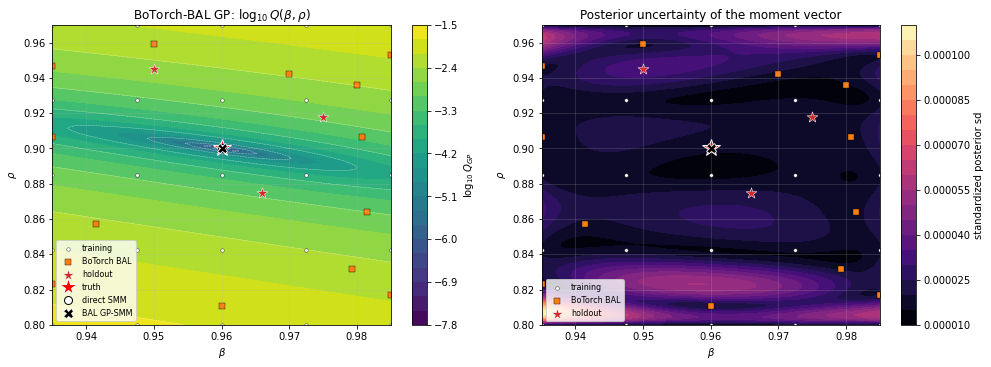

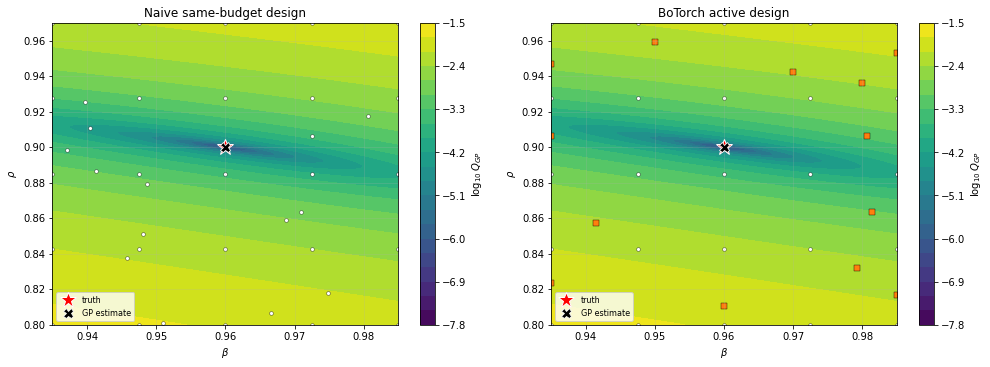

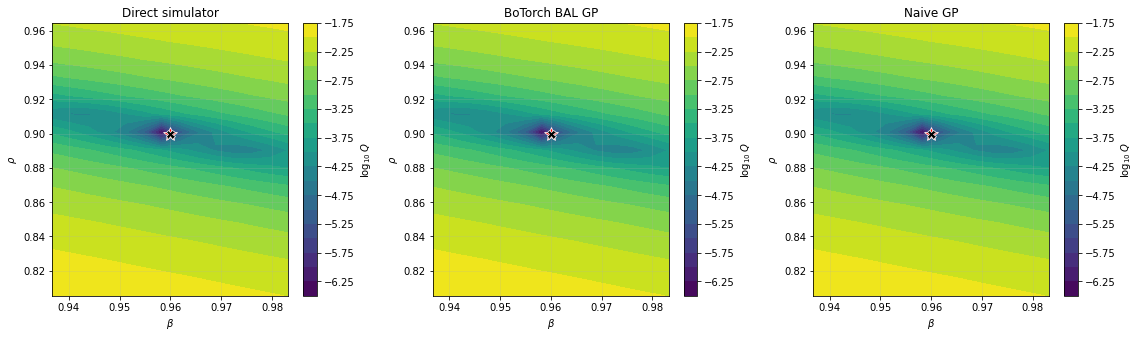

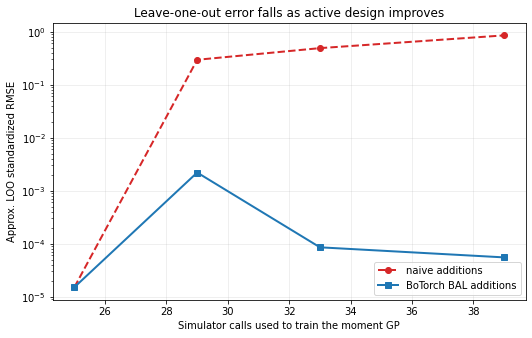

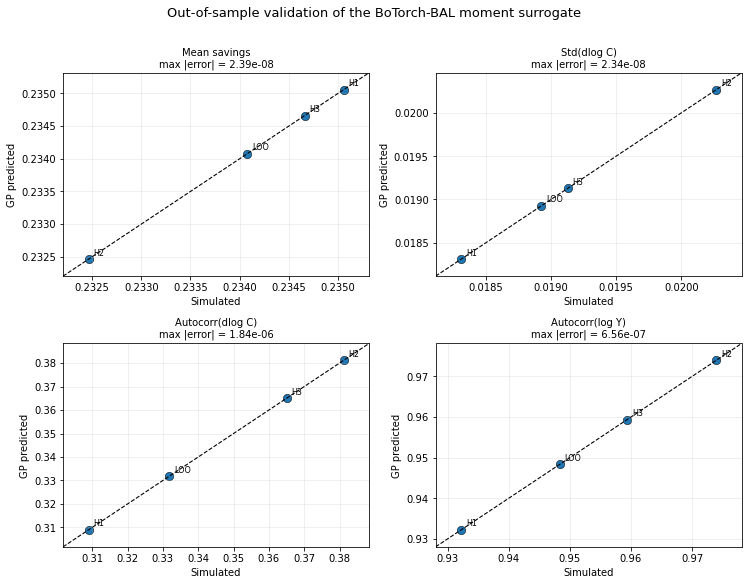

In [18]:
# Dense grids for plotting the final BoTorch-BAL GP objective and uncertainty.
beta_plot_gp = np.linspace(gp_beta_min, gp_beta_max, 120)
rho_plot_gp  = np.linspace(gp_rho_min,  gp_rho_max,  120)
BB_gp, RR_gp = np.meshgrid(beta_plot_gp, rho_plot_gp, indexing="xy")
theta_plot_gp = np.column_stack([BB_gp.ravel(), RR_gp.ravel()])
mu_plot_gp, std_plot_gp = predict_moment_gps_joint(gps_moments_joint, theta_plot_gp, return_std=True)
Q_gp_plot = q_from_moments_joint(mu_plot_gp, mask_over).reshape(BB_gp.shape)
unc_gp_plot = np.sqrt(np.sum((std_plot_gp[:, mask_over] / np.maximum(np.std(moments_train[:, mask_over], axis=0), 1e-8)) ** 2, axis=1)).reshape(BB_gp.shape)

# Direct-vs-GP validation of the objective on a fresh offset grid.
beta_edges = np.linspace(gp_beta_min, gp_beta_max, 15)
rho_edges  = np.linspace(gp_rho_min,  gp_rho_max,  17)
beta_check = 0.5 * (beta_edges[:-1] + beta_edges[1:])
rho_check  = 0.5 * (rho_edges[:-1]  + rho_edges[1:])
BB_check, RR_check = np.meshgrid(beta_check, rho_check, indexing="xy")
theta_check = np.column_stack([BB_check.ravel(), RR_check.ravel()])

Q_direct_check = np.array([smm_criterion(b, r, mask_over) for b, r in theta_check]).reshape(BB_check.shape)
mu_check_bal = predict_moment_gps_joint(gps_moments_joint, theta_check)
mu_check_naive = predict_moment_gps_joint(gps_moments_naive, theta_check)
Q_gp_check_bal = q_from_moments_joint(mu_check_bal, mask_over).reshape(BB_check.shape)
Q_gp_check_naive = q_from_moments_joint(mu_check_naive, mask_over).reshape(BB_check.shape)
logQ_direct = np.log10(np.maximum(Q_direct_check, 1e-14))
logQ_bal = np.log10(np.maximum(Q_gp_check_bal, 1e-14))
logQ_naive = np.log10(np.maximum(Q_gp_check_naive, 1e-14))
logQ_abs_error_bal = np.abs(logQ_bal - logQ_direct)
logQ_abs_error_naive = np.abs(logQ_naive - logQ_direct)

print("Objective-surface validation on a fresh offset grid")
print(f"  naive median |log10 Q_GP - log10 Q_direct| = {np.median(logQ_abs_error_naive):.3e}")
print(f"  BAL   median |log10 Q_GP - log10 Q_direct| = {np.median(logQ_abs_error_bal):.3e}")
print(f"  naive max    |log10 Q_GP - log10 Q_direct| = {np.max(logQ_abs_error_naive):.3e}")
print(f"  BAL   max    |log10 Q_GP - log10 Q_direct| = {np.max(logQ_abs_error_bal):.3e}")

# Plot the 2D GP objective surrogate and its uncertainty.
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

ax = axes[0]
cs = ax.contourf(BB_gp, RR_gp, np.log10(np.maximum(Q_gp_plot, 1e-12)), levels=22, cmap="viridis")
ax.contour(BB_gp, RR_gp, np.log10(np.maximum(Q_gp_plot, 1e-12)), levels=10, colors="white", linewidths=0.5, alpha=0.55)
ax.scatter(theta_bal[:, 0], theta_bal[:, 1], c="white", s=13, edgecolor="black", linewidth=0.35, label="training")
ax.scatter(theta_bal_added[:, 0], theta_bal_added[:, 1], c="#ff7f0e", marker="s", s=30, edgecolor="black", linewidth=0.4, label="BoTorch BAL")
ax.scatter(theta_holdout[:, 0], theta_holdout[:, 1], c="#d62728", marker="*", s=130, edgecolor="white", linewidth=0.5, label="holdout")
ax.plot(beta_true, rho_true, "*", ms=18, color="red", mec="white", mew=1.0, label="truth")
ax.plot(bhat_over, rhat_over, "o", ms=8, color="white", mec="black", mew=1.0, label="direct SMM")
ax.plot(bhat_gp, rhat_gp, "X", ms=10, color="black", mec="white", mew=0.8, label="BAL GP-SMM")
ax.set_xlabel(r"$\beta$"); ax.set_ylabel(r"$\varrho$")
ax.set_title(r"BoTorch-BAL GP: $\log_{10} Q(\beta,\varrho)$")
ax.legend(loc="lower left", fontsize=8)
plt.colorbar(cs, ax=ax, label=r"$\log_{10} Q_{GP}$")

ax = axes[1]
cs = ax.contourf(BB_gp, RR_gp, unc_gp_plot, levels=22, cmap="magma")
ax.scatter(theta_bal[:, 0], theta_bal[:, 1], c="white", s=13, edgecolor="black", linewidth=0.35, label="training")
ax.scatter(theta_bal_added[:, 0], theta_bal_added[:, 1], c="#ff7f0e", marker="s", s=30, edgecolor="black", linewidth=0.4, label="BoTorch BAL")
ax.scatter(theta_holdout[:, 0], theta_holdout[:, 1], c="#d62728", marker="*", s=130, edgecolor="white", linewidth=0.5, label="holdout")
ax.plot(beta_true, rho_true, "*", ms=18, color="red", mec="white", mew=1.0)
ax.plot(bhat_gp, rhat_gp, "X", ms=10, color="black", mec="white", mew=0.8)
ax.set_xlabel(r"$\beta$"); ax.set_ylabel(r"$\varrho$")
ax.set_title("Posterior uncertainty of the moment vector")
ax.legend(loc="lower left", fontsize=8)
plt.colorbar(cs, ax=ax, label="standardized posterior sd")

plt.tight_layout()
plt.savefig(fig_dir / "joint_gp_objective_surrogate.pdf", bbox_inches="tight")
plt.show()

# Naive vs BoTorch active design comparison.
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
for ax, label, theta_d, gps_d, est_marker in [
    (axes[0], "Naive same-budget design", theta_naive, gps_moments_naive, estimates_gp["naive"][0]),
    (axes[1], "BoTorch active design", theta_bal, gps_moments_joint, estimates_gp["botorch BAL"][0]),
]:
    mu_d = predict_moment_gps_joint(gps_d, theta_plot_gp)
    Q_d = q_from_moments_joint(mu_d, mask_over).reshape(BB_gp.shape)
    cs = ax.contourf(BB_gp, RR_gp, np.log10(np.maximum(Q_d, 1e-12)), levels=20, cmap="viridis")
    ax.scatter(theta_d[:, 0], theta_d[:, 1], c="white", s=14, edgecolor="black", linewidth=0.35)
    if label.startswith("BoTorch"):
        ax.scatter(theta_bal_added[:, 0], theta_bal_added[:, 1], c="#ff7f0e", marker="s", s=30, edgecolor="black", linewidth=0.4)
    ax.plot(beta_true, rho_true, "*", ms=17, color="red", mec="white", mew=1.0, label="truth")
    ax.plot(est_marker[0], est_marker[1], "X", ms=10, color="black", mec="white", mew=0.8, label="GP estimate")
    ax.set_xlabel(r"$\beta$"); ax.set_ylabel(r"$\varrho$")
    ax.set_title(label)
    ax.legend(loc="lower left", fontsize=8)
    plt.colorbar(cs, ax=ax, label=r"$\log_{10} Q_{GP}$")
plt.tight_layout()
plt.savefig(fig_dir / "joint_gp_bal_vs_naive.pdf", bbox_inches="tight")
plt.show()

# Fresh objective-grid comparison: direct vs BAL vs naive.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, Z, title in [
    (axes[0], logQ_direct, "Direct simulator"),
    (axes[1], logQ_bal,    "BoTorch BAL GP"),
    (axes[2], logQ_naive,  "Naive GP"),
]:
    cs = ax.contourf(BB_check, RR_check, Z, levels=18, cmap="viridis")
    ax.plot(beta_true, rho_true, "*", ms=15, color="red", mec="white", mew=0.8)
    ax.plot(bhat_gp, rhat_gp, "X", ms=9, color="black", mec="white", mew=0.7)
    ax.set_xlabel(r"$\beta$"); ax.set_ylabel(r"$\varrho$")
    ax.set_title(title)
    plt.colorbar(cs, ax=ax, label=r"$\log_{10} Q$")
plt.tight_layout()
plt.savefig(fig_dir / "joint_gp_objective_validation.pdf", bbox_inches="tight")
plt.show()

# LOO learning curve.
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(budget_grid, loo_naive, "o--", color="#d62728", lw=2.0, label="naive additions")
ax.plot(budget_grid, loo_bal, "s-", color="#1f77b4", lw=2.0, label="BoTorch BAL additions")
ax.set_xlabel("Simulator calls used to train the moment GP")
ax.set_ylabel("Approx. LOO standardized RMSE")
ax.set_title("Leave-one-out error falls as active design improves")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.savefig(fig_dir / "joint_gp_loo_learning_curve.pdf", bbox_inches="tight")
plt.show()

# Predicted-vs-simulated validation by moment. Separate panels avoid mixing scales.
true_vals = true_vals_validation
pred_vals = pred_vals_validation
fig, axes = plt.subplots(2, 2, figsize=(10.5, 8.0))
axes = axes.ravel()
for j, (ax, name) in enumerate(zip(axes, moment_names)):
    x = true_vals[:, j]
    y = pred_vals[:, j]
    err = y - x
    ax.scatter(x, y, s=70, color="#1f77b4", edgecolor="black", linewidth=0.5)
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    pad = 0.10 * (hi - lo + 1e-12)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color="black", ls="--", lw=1.1)
    for k, label in enumerate(["LOO", "H1", "H2", "H3"]):
        ax.annotate(label, (x[k], y[k]), textcoords="offset points", xytext=(5, 4), fontsize=8)
    ax.set_xlim(lo - pad, hi + pad); ax.set_ylim(lo - pad, hi + pad)
    ax.set_title(f"{name}\nmax |error| = {np.max(np.abs(err)):.2e}", fontsize=10)
    ax.set_xlabel("Simulated"); ax.set_ylabel("GP predicted")
plt.suptitle("Out-of-sample validation of the BoTorch-BAL moment surrogate", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(fig_dir / "joint_gp_validation.pdf", bbox_inches="tight")
plt.show()


### What to take away from the active-design comparison

The three GP designs answer different questions.

- The **pilot grid** is deliberately sparse. It is enough to see the broad shape of the local moment map, but its GP-SMM estimate can still move noticeably in the weakly identified $\beta$ direction.
- The **naive same-budget design** spends additional calls broadly. It often recovers the point estimate well, but the leave-one-out curve can deteriorate because random additions create uneven local geometry for a small deterministic GP.
- The **BoTorch BAL design** spends the same number of simulator calls as the naive design, but places them where they are useful for estimation: near low SMM values and in regions where the moment GP remains uncertain. The printed tables should therefore be read jointly: the final point estimates are all very close to the truth, while the active design gives much better holdout interpolation, a lower maximum objective-surface error, and a far more stable leave-one-out curve.

This is the practical lesson for structural estimation. Active learning is not magic global approximation. It is a way to spend scarce simulator calls inside the trust region where the estimator actually needs the surrogate to be accurate.

## Summary

This notebook teaches the second half of the surrogate-SMM lesson: **what changes when one of the parameters is partially identified.**

- The 4-input pseudo-state surrogate is trained once on $\beta \in [0.92, 0.99]\times\varrho \in [0.50, 0.99]$ and re-used inside every SMM evaluation. **No re-solving** the model during the optimizer's line-search.
- The just-identified objective (2 moments) leaves a **visible ridge** along $\beta$ --- exactly the partial-identification problem that motivates the everyday calibration practice of pegging $\beta$ to a target interest rate.
- Adding moments tightens identification: the over-identified objective (4 moments) collapses the ridge to a localized minimum; the optimizer recovers $(\beta, \varrho)$ close to $(0.96, 0.90)$ in this synthetic CRN run and the matched moments are small.
- The interior-solution check confirms that the optimizer is not pinned at a boundary, which is required for the standard asymptotic distribution theory to apply.
- The final GP section adds a second-layer **moment-map surrogate** over $(\beta,\varrho) \mapsto m(\beta,\varrho)$, uses BoTorch active learning to choose informative design points, compares the active design against a same-budget naive design, reports leave-one-out learning curves, validates fresh holdouts and a direct-vs-GP objective grid, and then solves the GP-implied SMM problem locally.

Together with `03_Structural_Estimation_BM.ipynb`, this completes the 1-parameter $\to$ 2-parameter progression of the structural-estimation workflow with deep policy surrogates and validated GP moment surrogates.